In [65]:
import pandas as pd
import os

def clean_energy_report_optimized(file_path):
    # Load raw data - using 'engine' to handle complex xlsx if needed
    df = pd.read_excel(file_path, header=None, skiprows=9)
    
    # 1. Immediate De-fragmentation: 
    # Drop completely empty columns first to reduce the width
    df = df.dropna(axis=1, how='all').copy() 
    
    # 2. Extract Metadata safely
    # Forward fill the categories in the first column
    categories = df[0].ffill()
    metrics = df[1]
    
    # Combine them into a Series instead of adding to the wide DataFrame immediately
    metric_ids = categories.astype(str) + " | " + metrics.astype(str)
    
    # 3. Strip the metadata columns and Transpose
    # We slice out the actual numeric data (columns index 2 and onwards)
    data_only = df.iloc[:, 2:].copy()
    data_only.index = metric_ids
    
    # Transpose: Metrics become columns
    df_tidy = data_only.T
    
    # 4. Force a fresh memory block allocation
    return df_tidy.copy()

In [66]:
all_files = [f for f in os.listdir("../data/Bronze/xlsx") if f.endswith('.xlsx')][:10]
data = []
for file in all_files:
    cleaned_data = clean_energy_report_optimized(os.path.join("../data/Bronze/xlsx", file))
    data.append(cleaned_data)
final_df = pd.concat(data, ignore_index=True)

In [67]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12873 entries, 0 to 12872
Data columns (total 54 columns):
 #   Column                                                                 Non-Null Count  Dtype 
---  ------                                                                 --------------  ----- 
 0   nan                                                                    8831 non-null   object
 1   nan                                                                    8831 non-null   object
 2   Consommation gaz | Consommation du gaz naturel moteur en Nm3 (Volume)  12873 non-null  object
 3   Consommation gaz | Puissance électrique nette                          0 non-null      object
 4   Consommation gaz | Débit du gaz naturel moteur en Nm3/h                12873 non-null  object
 5   Consommation Auxiliare | Energie éléctrique en KWh                     12873 non-null  object
 6   Energie Moteur | Puissance électrique Brute en KW                      12873 non-null  object
 7   Energi

In [68]:
final_df.dropna(how='all', inplace=True)
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12873 entries, 0 to 12872
Data columns (total 54 columns):
 #   Column                                                                 Non-Null Count  Dtype 
---  ------                                                                 --------------  ----- 
 0   nan                                                                    8831 non-null   object
 1   nan                                                                    8831 non-null   object
 2   Consommation gaz | Consommation du gaz naturel moteur en Nm3 (Volume)  12873 non-null  object
 3   Consommation gaz | Puissance électrique nette                          0 non-null      object
 4   Consommation gaz | Débit du gaz naturel moteur en Nm3/h                12873 non-null  object
 5   Consommation Auxiliare | Energie éléctrique en KWh                     12873 non-null  object
 6   Energie Moteur | Puissance électrique Brute en KW                      12873 non-null  object
 7   Energi

In [69]:
final_df.shape

(12873, 54)

In [70]:
final_df.head()

,NaN,NaN,Consommation gaz | Consommation du gaz naturel moteur en Nm3 (Volume),Consommation gaz | Puissance électrique nette,Consommation gaz | Débit du gaz naturel moteur en Nm3/h,Consommation Auxiliare | Energie éléctrique en KWh,Energie Moteur | Puissance électrique Brute en KW,Energie Moteur | heure de fonctionnement,Energie Moteur | Energie éléctrique au borne de l'alternateur en KWh,Energie Moteur | Energie reactive en KVARh,...,Energymeter eau chaude Gamma | Puissance en KW,Energymeter eau chaude Gamma | Consigne de Température,Energymeter eau chaude Gamma | Lecture de Temperature,Rendement | Rendement Electrique %,Rendement | Rendement Thermique %,Rendement | Rendement Total %,Achat et vente | Energie Positive Steg KWh,Achat et vente | Energie Negative Steg KWh,Achat et vente | Energie Positive Production KWh,Achat et vente | Energie Negative Production KWh
0,20/05/2025,00:00:00,2334978,NaN,273.35,708819.1,1199,8774,10440510,2046352,...,60.36,80,71,41.77,19.81,61.59,807427,4287283,9702460,13455
1,20/05/2025,00:02:48,2334978,NaN,273.35,708822.3,1196,8774,10440570,2046357,...,60.36,80,71,41.67,27.24,68.91,807427,4287305,9702512,13455
2,NaN,NaN,2335061.0,NaN,273.55,708838.5,1205.0,8775.0,10440770.0,2046371.0,...,60.36,80.0,71.0,NaN,NaN,NaN,807427.0,4287384.0,9702695.0,13455.0
3,20/05/2025,00:12:48,2335132,NaN,273.64,708855.6,1202,8775,10440970,2046386,...,60.36,80,71,41.95,27.4,69.35,807427,4287460,9702877,13455
4,NaN,NaN,2335179.0,NaN,273.38,708870.4,1203.0,8775.0,10441170.0,2046401.0,...,60.36,80.0,71.0,NaN,NaN,NaN,807427.0,4287538.0,9703062.0,13455.0


In [71]:
final_df.drop(columns=cleaned_data.columns[0], inplace=True)

In [72]:
final_df.columns

Index(['Consommation gaz | Consommation du gaz naturel moteur en Nm3 (Volume)',
       'Consommation gaz | Puissance électrique nette',
       'Consommation gaz | Débit du gaz naturel moteur en Nm3/h',
       'Consommation Auxiliare | Energie éléctrique en KWh',
       'Energie Moteur | Puissance électrique Brute en KW',
       'Energie Moteur | heure de fonctionnement',
       'Energie Moteur | Energie éléctrique au borne de l'alternateur en KWh',
       'Energie Moteur | Energie reactive en KVARh',
       'Energie Moteur | Vitesse en rpm',
       'Energie Moteur | Facteur de puissance',
       'Energie Moteur | Voltage en V',
       'Energie Moteur | Courant: phase 1 en A',
       'Energie Moteur | Courant: phase 2 en A',
       'Energie Moteur | Courant: phase 3 en A',
       'Energymeter eau glacée | Débit en m3/h (FM01)',
       'Energymeter eau glacée | Temperature entrée  (TT02)',
       'Energymeter eau glacée | Temperature sortie (TT01)',
       'Energymeter eau glacée | Energ

In [73]:
final_df["Natural Gas Consumption (kWh)"] = final_df["Consommation gaz | Consommation du gaz naturel moteur en Nm3 (Volume)"] * 1.99

In [74]:
def add_energy_balance_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates Energy Input, Output, and Losses (Delta).
    Standardizes units to kW (Power) or kWh (Energy) for comparison.
    """
    # --- 1. CONSTANTS ---
    # LHV (Lower Heating Value) for Tunisian Natural Gas ~ 10.55 kWh/Nm3
    LHV_GAS = 10.55 

    # --- 2. COLUMN MAPPING (Using your provided names) ---
    col_gas_flow = 'Consommation gaz | Débit du gaz naturel moteur en Nm3/h'
    col_elec_prod = 'Energie Moteur | Puissance électrique Brute en KW'
    col_heat_prod = 'Energymeter eau chaude récupéré | Puissance en KW'
    col_cold_prod = 'Energymeter eau glacée | Puissance en KW'

    # Ensure columns exist and are numeric
    cols_to_fix = [col_gas_flow, col_elec_prod, col_heat_prod, col_cold_prod]
    for col in cols_to_fix:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # --- 3. FEATURE CREATION ---

    # Feature 1: Sum of Input Energy (Power In)
    # Gas Flow (Nm3/h) * Energy Density (kWh/Nm3) = Power In (kW)
    df['feature_input_energy_kw'] = df[col_gas_flow] * LHV_GAS

    # Feature 2: Sum of Output Energy (Useful Power Out)
    # Sum of Electricity + Useful Heat + Useful Cold
    df['feature_output_energy_kw'] = (
        df[col_elec_prod] + 
        df[col_heat_prod] + 
        df[col_cold_prod]
    )

    # Feature 3: The Difference (Losses / Delta)
    # Representing the energy lost to the atmosphere (Exhaust gas + Radiation)
    df['feature_energy_delta_kw'] = (
        df['feature_input_energy_kw'] - df['feature_output_energy_kw']
    )

    # Bonus: Instantaneous Efficiency %
    # Helpful for anomaly detection (should be between 70% and 90% for Trigeneration)
    df['feature_total_efficiency_pct'] = (
        df['feature_output_energy_kw'] / df['feature_input_energy_kw'].replace(0, 1)
    ) * 100

    return df
final_df = add_energy_balance_features(final_df)
final_df.head()

,Consommation gaz | Consommation du gaz naturel moteur en Nm3 (Volume),Consommation gaz | Puissance électrique nette,Consommation gaz | Débit du gaz naturel moteur en Nm3/h,Consommation Auxiliare | Energie éléctrique en KWh,Energie Moteur | Puissance électrique Brute en KW,Energie Moteur | heure de fonctionnement,Energie Moteur | Energie éléctrique au borne de l'alternateur en KWh,Energie Moteur | Energie reactive en KVARh,Energie Moteur | Vitesse en rpm,Energie Moteur | Facteur de puissance,...,Rendement | Rendement Total %,Achat et vente | Energie Positive Steg KWh,Achat et vente | Energie Negative Steg KWh,Achat et vente | Energie Positive Production KWh,Achat et vente | Energie Negative Production KWh,Natural Gas Consumption (kWh),feature_input_energy_kw,feature_output_energy_kw,feature_energy_delta_kw,feature_total_efficiency_pct
0,2334978,NaN,273.35,708819.1,1199,8774,10440510,2046352,1502,0.99,...,61.59,807427,4287283,9702460,13455,4646606.22,2883.8425,1905.66,978.1825,66.080585
1,2334978,NaN,273.35,708822.3,1196,8774,10440570,2046357,1498.7,0.99,...,68.91,807427,4287305,9702512,13455,4646606.22,2883.8425,2065.70,818.1425,71.630125
2,2335061.0,NaN,273.55,708838.5,1205,8775.0,10440770.0,2046371.0,1499.1,0.99,...,NaN,807427.0,4287384.0,9702695.0,13455.0,4646771.39,2885.9525,2090.66,795.2925,72.442634
3,2335132,NaN,273.64,708855.6,1202,8775,10440970,2046386,1501.3,0.99,...,69.35,807427,4287460,9702877,13455,4646912.68,2886.9020,2037.15,849.7520,70.565263
4,2335179.0,NaN,273.38,708870.4,1203,8775.0,10441170.0,2046401.0,1500.2,0.99,...,NaN,807427.0,4287538.0,9703062.0,13455.0,4647006.21,2884.1590,2019.72,864.4390,70.028039


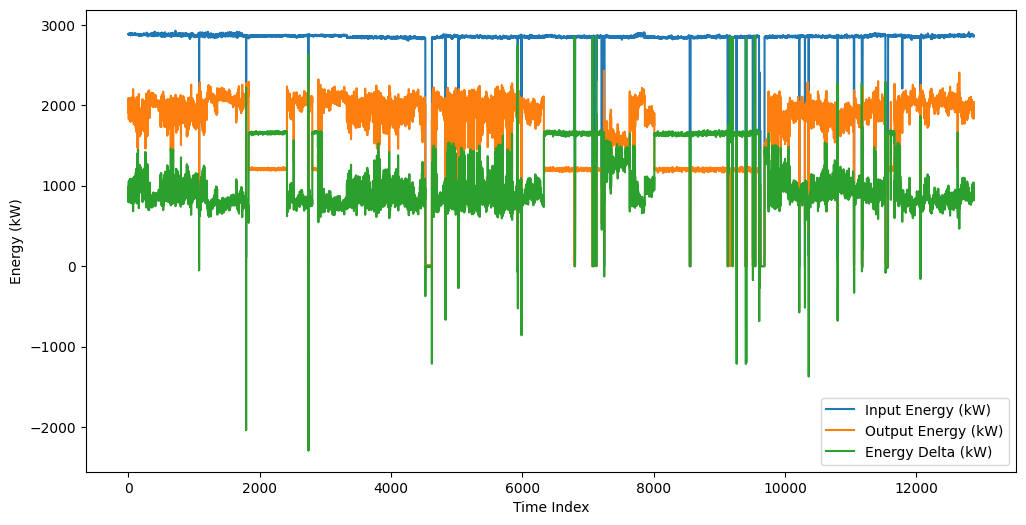

In [75]:
from matplotlib import pyplot as plt


plt.figure(figsize=(12, 6))
plt.plot(final_df['feature_input_energy_kw'], label='Input Energy (kW)')
plt.plot(final_df['feature_output_energy_kw'], label='Output Energy (kW)')
plt.plot(final_df['feature_energy_delta_kw'], label='Energy Delta (kW)')
plt.xlabel('Time Index')
plt.ylabel('Energy (kW)')
plt.legend()
plt.show()

In [76]:
final_df["feature_total_efficiency_pct"].mean()

np.float64(194.99482975889214)

In [84]:
col_name = 'feature_energy_delta_kw'
new_df = final_df[(final_df[col_name] >0)]



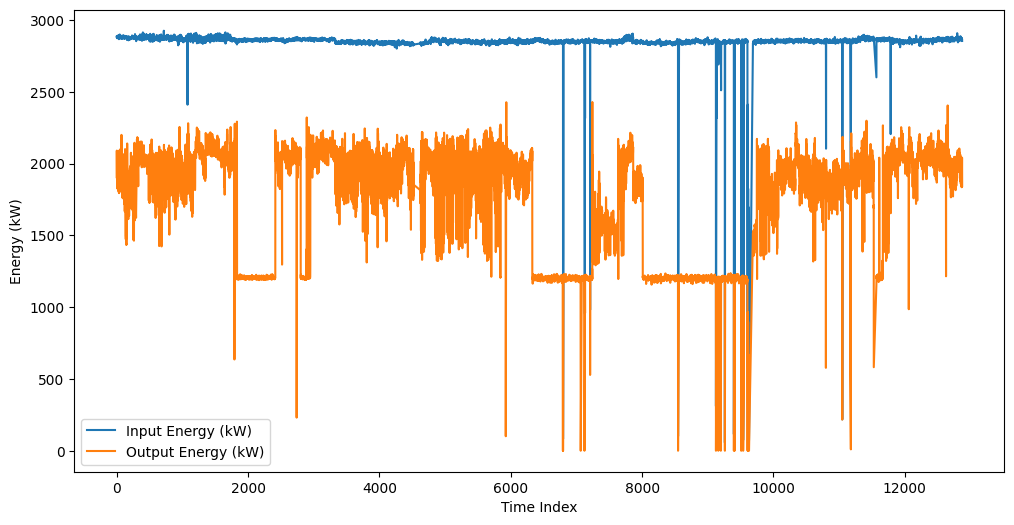

In [86]:
plt.figure(figsize=(12, 6))
plt.plot(new_df['feature_input_energy_kw'], label='Input Energy (kW)')
plt.plot(new_df['feature_output_energy_kw'], label='Output Energy (kW)')
#plt.plot(new_df['feature_energy_delta_kw'], label='Energy Delta (kW)')
plt.xlabel('Time Index')
plt.ylabel('Energy (kW)')
plt.legend()
plt.show()

In [87]:
new_df.shape

(12566, 57)

In [89]:
new_df["feature_total_efficiency_pct"].mean()

np.float64(60.9770910546267)

In [ ]:
s = new_df["feature_total_efficiency_pct"].mean()

new_df["is_ano"] = new_df["feature_total_efficiency_pct"] < s

In [ ]:
new_df.drop(columns=['Consommation gaz | Puissance électrique nette'],inplace=True)


In [ ]:
for col in new_df.columns:
    new_df[col] = pd.to_numeric(new_df[col], errors='coerce').fillna(0)

In [97]:
new_df["is_ano"] = new_df["is_ano"].astype(int)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1615
           1       1.00      1.00      1.00       899

    accuracy                           1.00      2514
   macro avg       1.00      1.00      1.00      2514
weighted avg       1.00      1.00      1.00      2514



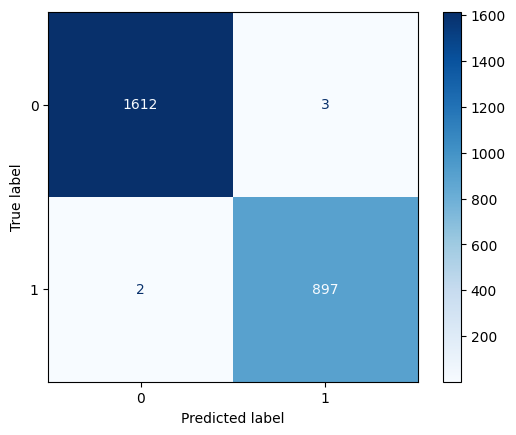

F1 Score: 0.9972206781545303


In [100]:
from sklearn.metrics import classification_report, confusion_matrix,f1_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split


X = new_df.drop(columns=['is_ano'])
y = new_df['is_ano']


model = XGBClassifier()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot(cmap=plt.cm.Blues)

plt.show()


print("F1 Score:", f1_score(y_test, y_pred))


In [101]:
new_df.to_csv("../data/Gold/energy_balance_features.csv", index=False)

In [ ]:
features = X_test.reset_index(drop=True)
pred = pd.DataFrame(y_pred,columns=['anomalie'])

res = pd.concat([features, pred], axis=1)
res.head()

Index(['Consommation gaz | Consommation du gaz naturel moteur en Nm3 (Volume)',
       'Consommation gaz | Débit du gaz naturel moteur en Nm3/h',
       'Consommation Auxiliare | Energie éléctrique en KWh',
       'Energie Moteur | Puissance électrique Brute en KW',
       'Energie Moteur | heure de fonctionnement',
       'Energie Moteur | Energie éléctrique au borne de l'alternateur en KWh',
       'Energie Moteur | Energie reactive en KVARh',
       'Energie Moteur | Vitesse en rpm',
       'Energie Moteur | Facteur de puissance',
       'Energie Moteur | Voltage en V',
       'Energie Moteur | Courant: phase 1 en A',
       'Energie Moteur | Courant: phase 2 en A',
       'Energie Moteur | Courant: phase 3 en A',
       'Energymeter eau glacée | Débit en m3/h (FM01)',
       'Energymeter eau glacée | Temperature entrée  (TT02)',
       'Energymeter eau glacée | Temperature sortie (TT01)',
       'Energymeter eau glacée | Energie en kWh ',
       'Energymeter eau glacée | Puissance 

In [ ]:
res.to_csv("../data/Gold/anomaly_detection_results.csv", index=False)